In [1]:
import yfinance as yf
import pandas as pd

tickers = [
    "AAPL",   # Apple
    "MSFT",   # Microsoft
    "GOOGL",  # Google
    "AMZN",   # Amazon
    "NVDA",   # Nvidia
    "TSLA",   # Tesla
    "META",   # Meta
    "JPM",    # JP Morgan
    "XOM",    # ExxonMobil
    "JNJ",    # Johnson & Johnson
]

stocks = {}

for ticker in tickers:
    df = yf.download(ticker, start="2019-01-01", end="2024-12-31")
    df.columns = df.columns.get_level_values(0)
    stocks[ticker] = df
    print(f"{ticker}: {df.shape}")

[*********************100%***********************]  1 of 1 completed


AAPL: (1509, 5)


[*********************100%***********************]  1 of 1 completed


MSFT: (1509, 5)


[*********************100%***********************]  1 of 1 completed


...

JPM: (1509, 5)


[*********************100%***********************]  1 of 1 completed


XOM: (1509, 5)


[*********************100%***********************]  1 of 1 completed

JNJ: (1509, 5)


In [11]:
for ticker, df in stocks.items():
    print(f"\n{'='*50}")
    print(f"السهم: {ticker}")
    print(f"{'='*50}")
    print(df.tail(1))


السهم: AAPL
Price            Close        High         Low        Open    Volume
Date                                                                
2024-12-30  250.829788  252.122728  249.387669  250.859624  35557500

السهم: MSFT
Price            Close        High         Low        Open    Volume
Date                                                                
2024-12-30  420.758698  423.452632  417.856784  421.976921  13158700

السهم: GOOGL
Price           Close        High         Low        Open    Volume
Date                                                               
2024-12-30  190.35994  191.663909  188.249685  188.926564  14264700

السهم: AMZN
Price            Close   High         Low        Open    Volume
Date                                                           
2024-12-30  221.300003  223.0  218.429993  220.059998  28321200

السهم: NVDA
Price            Close        High         Low        Open     Volume
Date                                                  

In [13]:
print("Missing values per stock:")
for ticker, df in stocks.items():
    missing = df.isnull().sum().sum()
    if missing > 0:
        print(f"{ticker}: {missing} missing values")
    else:
        print(f"{ticker}: No missing values")


Missing values per stock:
AAPL: No missing values
MSFT: No missing values
GOOGL: No missing values
AMZN: No missing values
NVDA: No missing values
TSLA: No missing values
META: No missing values
JPM: No missing values
XOM: No missing values
JNJ: No missing values


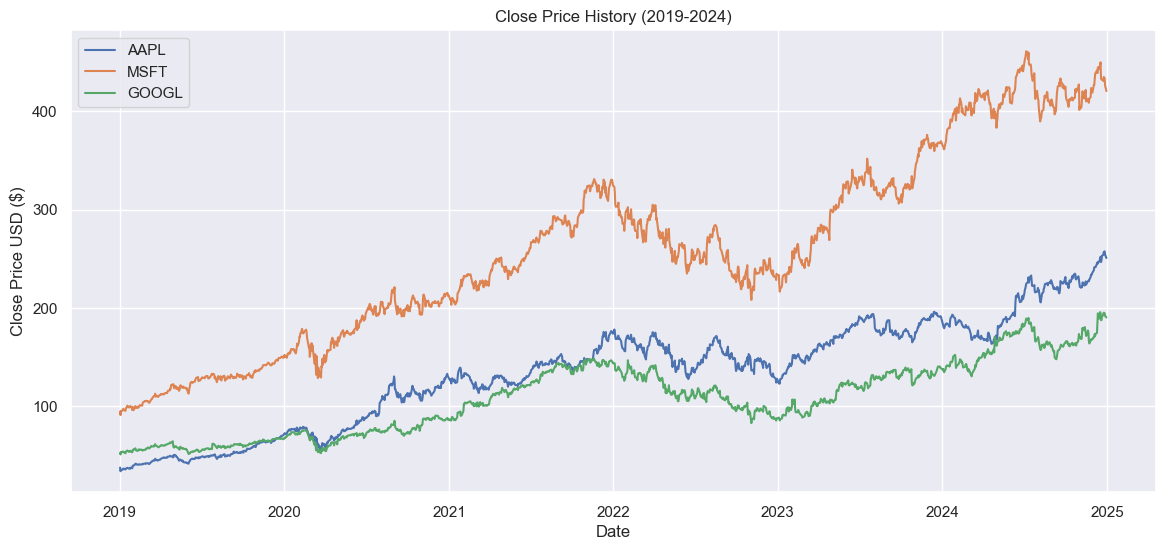

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.figure(figsize=(14, 6))

# try to draw 
for ticker in ['AAPL', 'MSFT', 'GOOGL']:
    plt.plot(stocks[ticker].index, stocks[ticker]['Close'], label=ticker)

plt.title('Close Price History (2019-2024)')
plt.xlabel('Date')
plt.ylabel('Close Price USD ($)')
plt.legend()
plt.show()


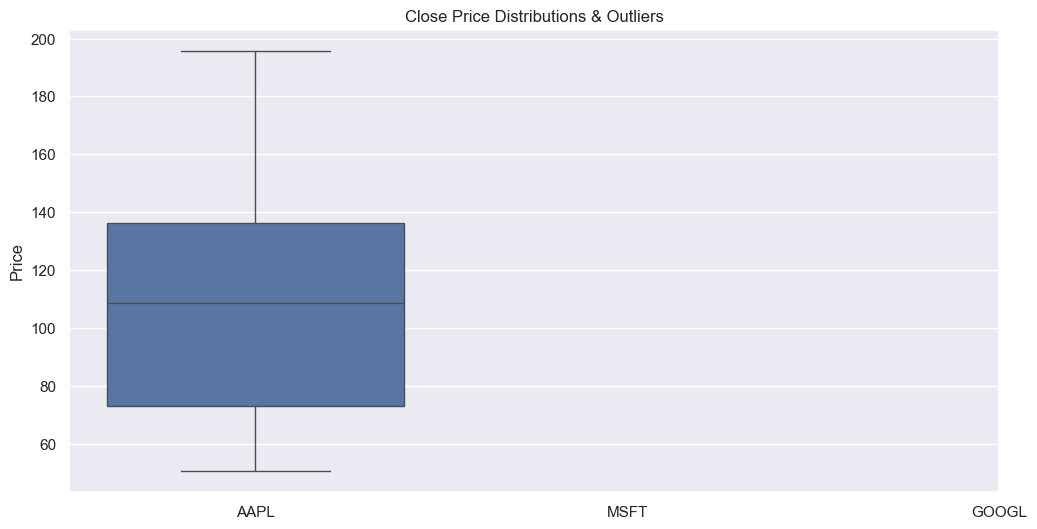

In [15]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=[stocks['AAPL']['Close'], stocks['MSFT']['Close'], stocks['GOOGL']['Close']])
plt.xticks([0, 1, 2], ['AAPL', 'MSFT', 'GOOGL'])
plt.title('Close Price Distributions & Outliers')
plt.ylabel('Price')
plt.show()


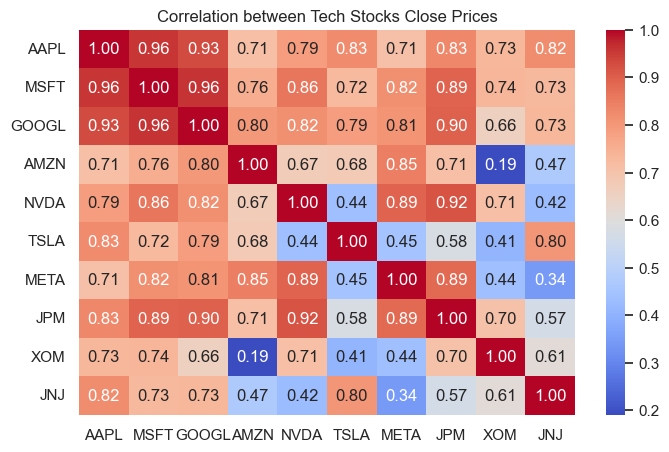

In [17]:
close_prices = pd.DataFrame({ticker: df['Close'] for ticker, df in stocks.items()})

plt.figure(figsize=(8, 5))
sns.heatmap(close_prices.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation between Tech Stocks Close Prices')
plt.show()
